In [10]:
from Tools.analysis_tools import *

In [11]:
# Percorso della cartella contenente i file CSV degli encoder
decoder_folder = "Decoder Analysis Data"

# Carica i dati
decoder_data = load_decoder_analysis_data(decoder_folder)

# Order the dataset
decoder_data = order_dataset_by_model(decoder_data)

# Visualizza i dati ordinati
print(decoder_data.head())


Caricando dati da: Decoder Analysis Data/5D,6,5.csv
Caricando dati da: Decoder Analysis Data/5D,0,0.csv
Caricando dati da: Decoder Analysis Data/5D,3,0-Deeper.csv
Caricando dati da: Decoder Analysis Data/5D,9,0.csv
Caricando dati da: Decoder Analysis Data/5D,6,0.csv
Caricando dati da: Decoder Analysis Data/5D,3,5.csv
Caricando dati da: Decoder Analysis Data/5D,3,0.csv
Caricando dati da: Decoder Analysis Data/5D,0,5.csv
Totale modelli caricati: 8
      Model Name  Latent Dim  Z1 R2 Mean  Z1 R2 Std  Z1 MSE Mean  Z1 MSE Std  \
1         5D,0,0           5    0.781773   0.215370     0.008600    0.008518   
2  5D,3,0-Deeper           5    0.756216   0.184019     0.010836    0.008533   
6         5D,3,0           5    0.832577   0.103646     0.007329    0.004396   
4         5D,6,0           5    0.805923   0.124561     0.008461    0.005317   
3         5D,9,0           5    0.782497   0.141168     0.009510    0.006023   

   Z1 MaxSE Mean  Z1 MaxSE Std  Z3 R2 Mean  Z3 R2 Std  ...  Z3 MaxSE 

### Metriche di ricostruzione per i vettori di Embedding di Z1 e Z3:
Plottiamo gli indici $R^2$, MSE, MAXse, normalizzati nell'intervallo $[0,1]$ per vedere quali modelli ricostruiscono meglio i vettori di embedding.
I valori massimi di una metrica valgono 1, i valori minimi valgono zero a causa della normalizzazione.

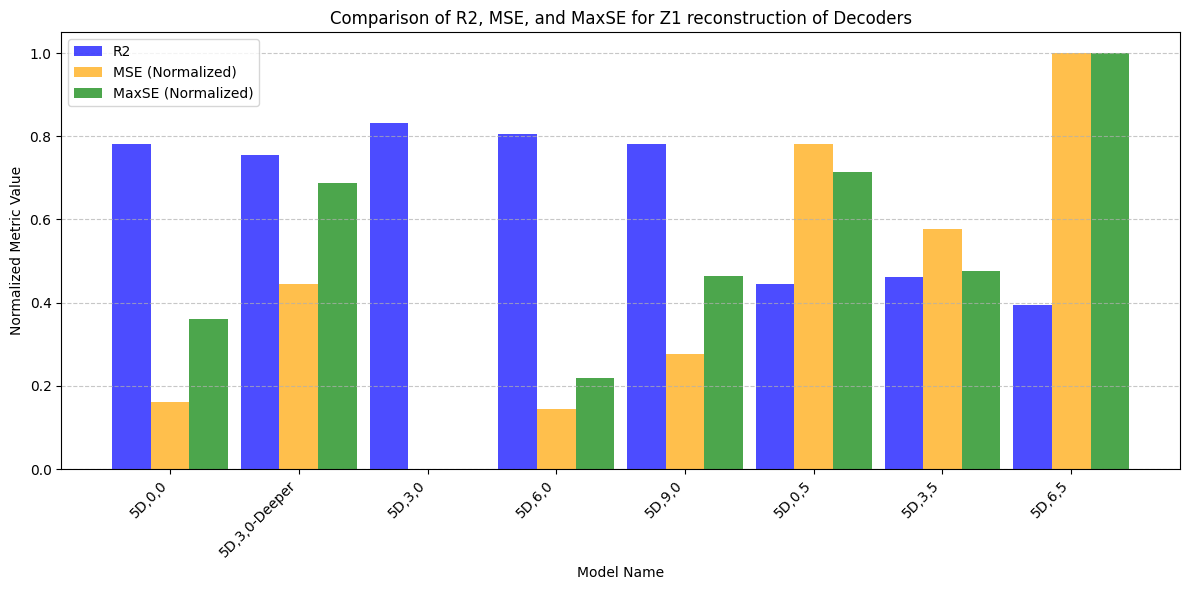

In [ ]:
plot_z_metrics(
    data=decoder_data, 
    r2_col="Z1 R2 Mean", 
    mse_col="Z1 MSE Mean", 
    maxse_col="Z1 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z1 reconstruction of Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!
# Disattivata normalizzazione di R^2


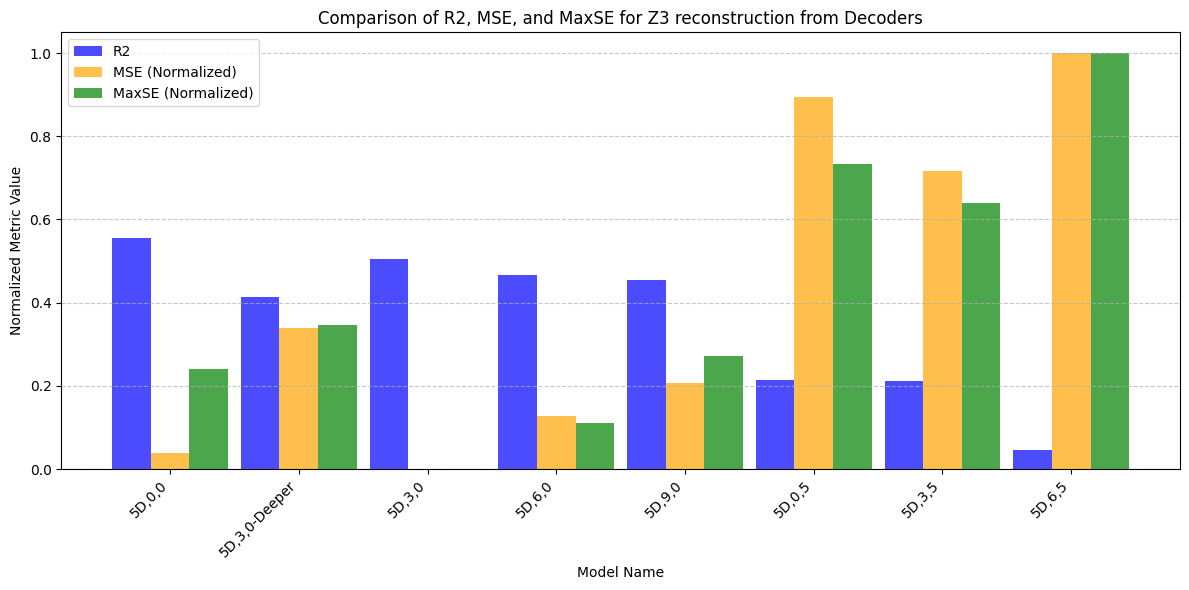

In [ ]:
plot_z_metrics(
    data=decoder_data, 
    r2_col="Z3 R2 Mean", 
    mse_col="Z3 MSE Mean", 
    maxse_col="Z3 MaxSE Mean", 
    title="Comparison of R2, MSE, and MaxSE for Z3 reconstruction from Decoders"
)
#PS: La colonna nulla significa che ha il valore minimo di quella metrica!


### Analisi della ricostruzione delle PC:
Sono state calcolate dagli embedding originali le PC tramite PCA ( usando scikit.learn), poi gli output della rete sono stati proiettati lungo le PC dei dati originali e sono stati calcolati gli $R^2$ per componente e la varianza spiegata.

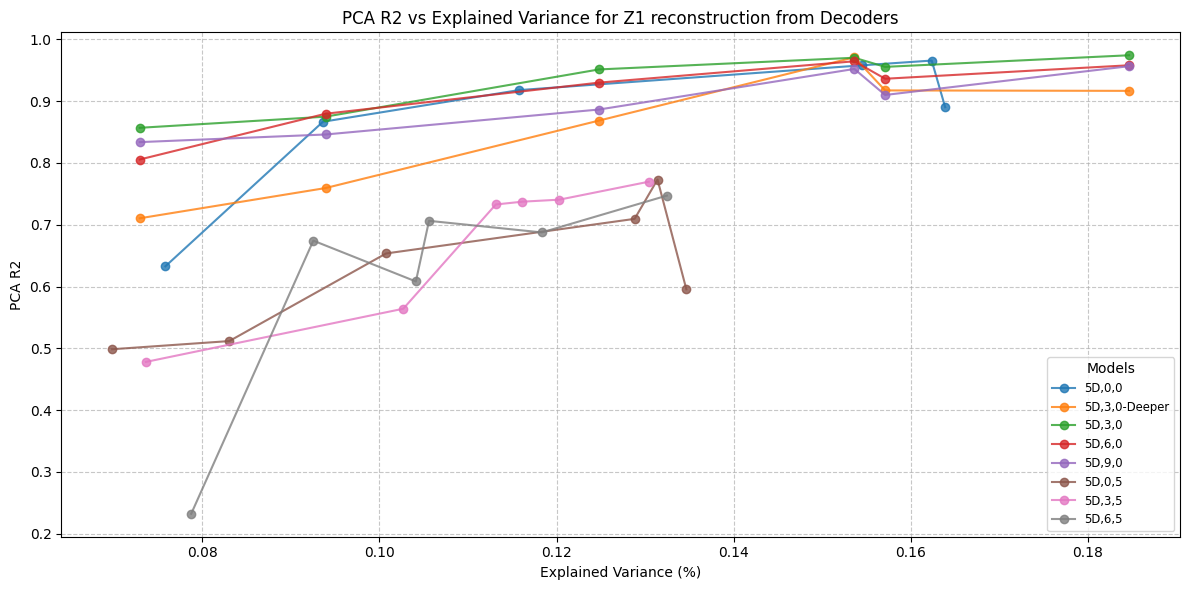

In [14]:
plot_pca_r2_and_variance(
    data=decoder_data,
    r2_col="PCA R2 Z1 PC",
    variance_col="Varianzce Explained Z1",
    title="PCA R2 vs Explained Variance for Z1 reconstruction from Decoders"
)

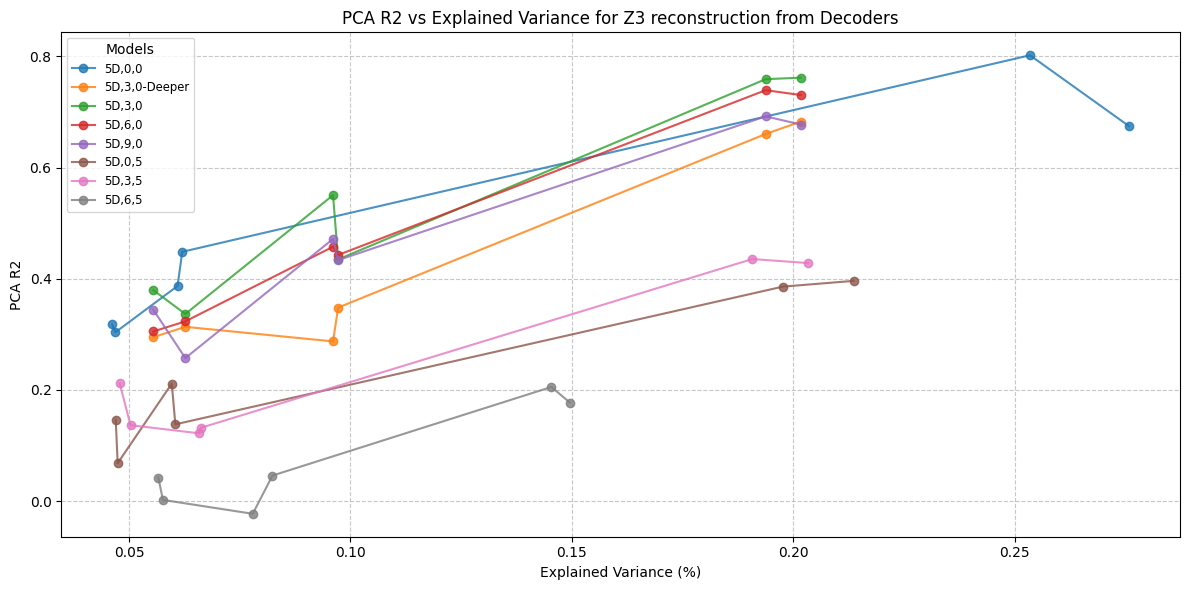

In [ ]:
plot_pca_r2_and_variance(
    data=decoder_data,
    r2_col="PCA R2 Z3 PC",
    variance_col="Varianzce Explained Z3",
    title="PCA R2 vs Explained Variance for Z3 reconstruction from Decoders"
)

In [ ]:
plot_r2_and_variance_separate(
    data=decoder_data, 
    r2_col="PCA R2 Z1 PC", 
    variance_col="Varianzce Explained Z1"
)
plot_r2_and_variance_separate(
    data=decoder_data, 
    r2_col="PCA R2 Z3 PC", 
    variance_col="Varianzce Explained Z3"
)

Adesso invece si fa lo stesso tipo di analisi ma usando al posto dei singoli embedding usati per calcolare le PC si utilizza una matrice in cui sono stati concatenati gli embedding di $Z_1$ e $Z_3$ ottenuti dai dati utilizzati. Dopo aver calcolato le PC in questo modo si sono proiettati gli embedding ottenuti dalla rete per vedere la capacitò della rete di ricostruire $Z_1$ e $Z_3$ in modo congiunto

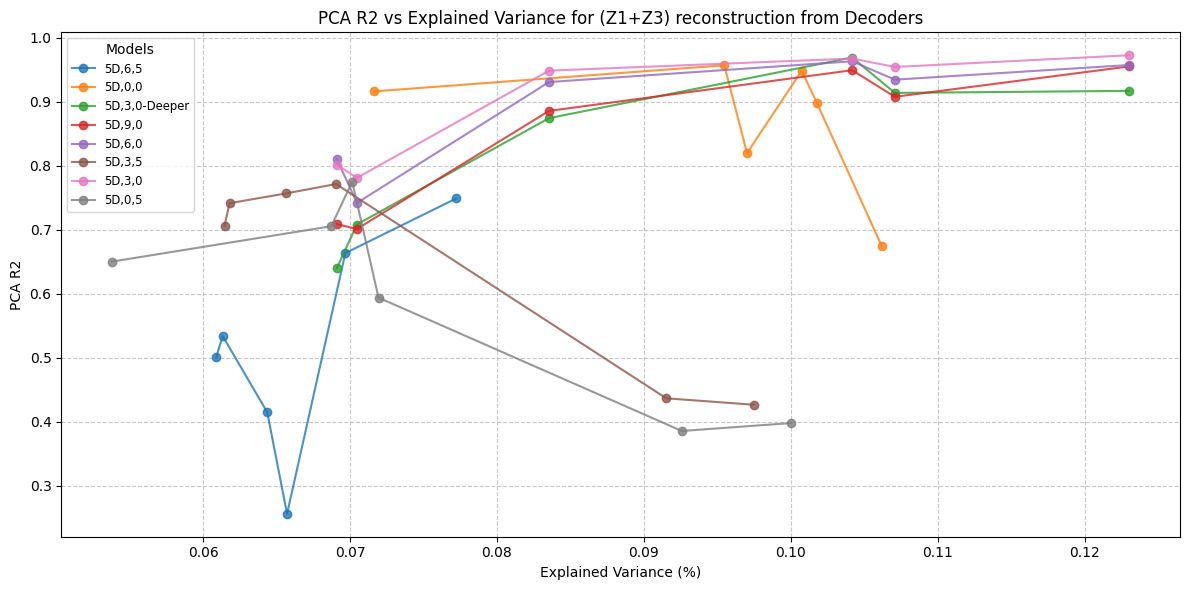

In [17]:
plot_pca_r2_and_variance(
    data=decoder_data,
    r2_col="PCA R2 (Z1+Z3) PC",
    variance_col="Variance Explained (Z1+Z3)",
    title="PCA R2 vs Explained Variance for (Z1+Z3) reconstruction from Decoders"
)

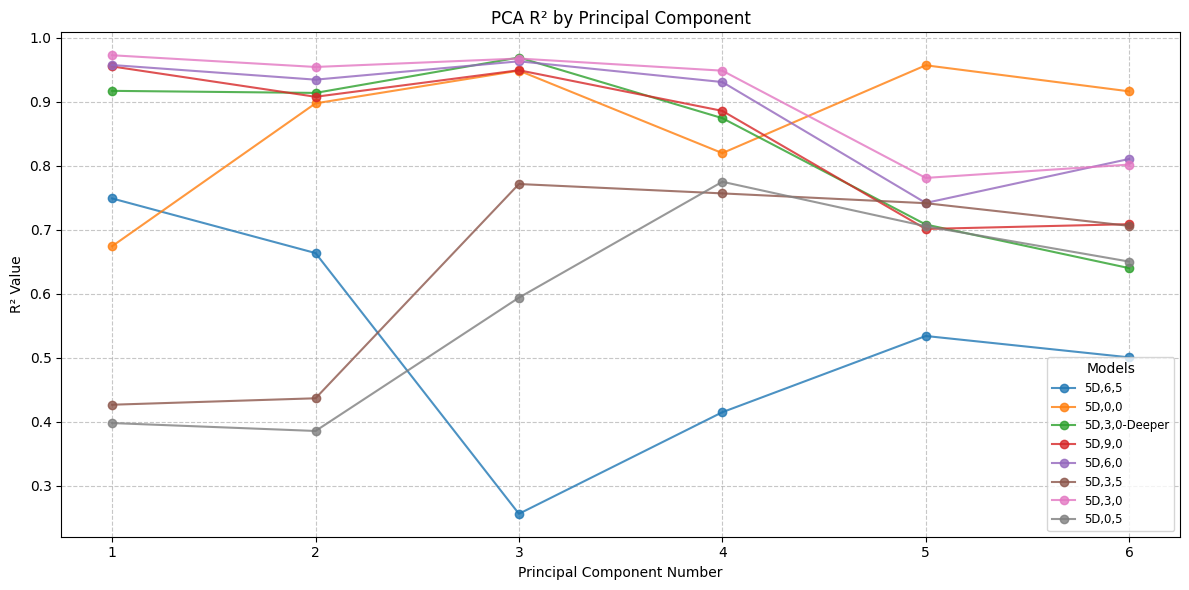

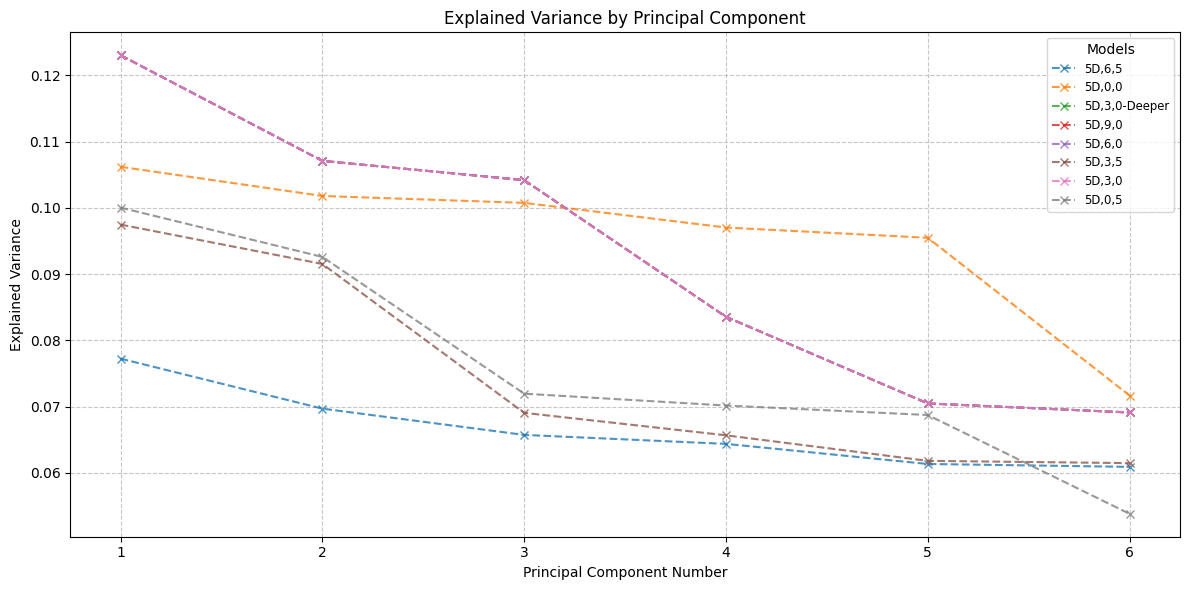

In [18]:
plot_r2_and_variance_separate(
    data=decoder_data, 
    r2_col="PCA R2 (Z1+Z3) PC", 
    variance_col="Variance Explained (Z1+Z3)"
)